# VAE Portfolio Project - VaR Calculation

This notebook calculates Value at Risk (VaR) for the portfolio using VAE-generated scenarios.

In [63]:
# Import libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from var_calculator import VaRCalculator, PortfolioVaRAnalyzer
from utils import PortfolioConfig

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [64]:
# Load configuration
config = PortfolioConfig()

# Load scenarios
scenarios = pd.read_csv('../results/scenarios.csv')
portfolio_returns = pd.read_csv('../results/portfolio_returns.csv')

print(f"Scenarios shape: {scenarios.shape}")
print(f"Portfolio returns shape: {portfolio_returns.shape}")

# Extract data
generated_scenarios = scenarios.values
generated_portfolio = portfolio_returns['generated'].values
historical_portfolio = portfolio_returns['historical'].values

Scenarios shape: (10000, 4)
Portfolio returns shape: (10000, 2)


## 2. Calculate VaR - Generated Scenarios

In [65]:
# Initialize calculator with generated portfolio returns
var_calc_generated = VaRCalculator(generated_portfolio, config.weights)

# Calculate VaR
var_summary_generated = var_calc_generated.var_summary(config.var_levels)

print("\n" + "="*70)
print("VaR CALCULATION - VAE GENERATED SCENARIOS")
print("="*70)
print(var_summary_generated.to_string())


VaR CALCULATION - VAE GENERATED SCENARIOS
  Confidence Level  Historical VaR  Parametric VaR      CVaR
0              95%       -0.013697       -0.012975 -0.020481
1              99%       -0.025045       -0.018548 -0.031323


In [66]:
## 2b. Stressed scenarios selection (from generated scenarios)
from utils import select_top_stressed_scenarios

# Choose a tail fraction from the shared configuration
tail_fraction = getattr(config, 'stress_tail_fraction', 0.1)
n_total = len(generated_scenarios)
n_stressed = max(1, int(n_total * tail_fraction))
print(f"Selecting top {n_stressed} worst scenarios out of {n_total} (tail_fraction={tail_fraction})")

selected_scenarios, selected_portfolio_returns, stress_scores = select_top_stressed_scenarios(
    generated_scenarios,
    weights=config.weights,
    top_k=n_stressed
)

# Compute VaR on the selected stressed portfolio returns
var_calc_stressed = VaRCalculator(selected_portfolio_returns, config.weights)
var_summary_stressed = var_calc_stressed.var_summary(config.var_levels)

print("\n" + "="*70)
print("VaR CALCULATION - SELECTED STRESSED SCENARIOS (from generated)")
print("="*70)
print(var_summary_stressed.to_string())

# Quick diagnostics
print(f"\nSelected stressed scenarios shape: {selected_scenarios.shape}")
print(f"Selected stressed portfolio returns - mean: {selected_portfolio_returns.mean():.6f}, std: {selected_portfolio_returns.std():.6f}")

# Save stressed scenarios and var summary
import pandas as pd
pd.DataFrame(selected_scenarios, columns=config.indices).to_csv('../results/stressed_scenarios.csv', index=False)
var_summary_stressed.to_csv('../results/var_generated_stressed.csv', index=False)
print('\nSaved stressed scenarios to ../results/stressed_scenarios.csv and stressed VaR to ../results/var_generated_stressed.csv')

Selecting top 1000 worst scenarios out of 10000 (tail_fraction=0.1)

VaR CALCULATION - SELECTED STRESSED SCENARIOS (from generated)
  Confidence Level  Historical VaR  Parametric VaR      CVaR
0              95%       -0.029491       -0.026780 -0.035534
1              99%       -0.040234       -0.031345 -0.043560

Selected stressed scenarios shape: (1000, 4)
Selected stressed portfolio returns - mean: -0.015762, std: 0.006698

Saved stressed scenarios to ../results/stressed_scenarios.csv and stressed VaR to ../results/var_generated_stressed.csv


## 3. Calculate VaR - Historical Data

In [67]:
# Load historical returns
historical_returns = pd.read_csv('../data/returns.csv', index_col=0)
historical_returns_array = historical_returns.values

# Calculate portfolio returns
historical_weights_normalized = config.weights / config.weights.sum()
historical_portfolio_calc = np.dot(historical_returns_array, historical_weights_normalized)

# Initialize calculator
var_calc_historical = VaRCalculator(historical_portfolio_calc, config.weights)

# Calculate VaR
var_summary_historical = var_calc_historical.var_summary(config.var_levels)

print("\n" + "="*70)
print("VaR CALCULATION - HISTORICAL DATA")
print("="*70)
print(var_summary_historical.to_string())


VaR CALCULATION - HISTORICAL DATA
  Confidence Level  Historical VaR  Parametric VaR      CVaR
0              95%       -0.014044       -0.015610 -0.023708
1              99%       -0.027278       -0.022163 -0.040559


## 4. Compare VaR Methods

In [68]:
# Create comparison table
comparison = pd.DataFrame({
    'Confidence': var_summary_generated['Confidence Level'],
    'Generated Historical': var_summary_generated['Historical VaR'],
    'Generated Parametric': var_summary_generated['Parametric VaR'],
    'Generated CVaR': var_summary_generated['CVaR'],
    'Historical Historical': var_summary_historical['Historical VaR'],
    'Historical Parametric': var_summary_historical['Parametric VaR'],
    'Historical CVaR': var_summary_historical['CVaR']
})

print("\n" + "="*100)
print("VaR COMPARISON: GENERATED vs HISTORICAL")
print("="*100)
print(comparison.to_string())

# Calculate differences
print("\n" + "="*100)
print("DIFFERENCES (Generated - Historical)")
print("="*100)
diff = comparison.copy()
for col in ['Generated Historical', 'Generated Parametric', 'Generated CVaR']:
    hist_col = col.replace('Generated ', 'Historical ')
    diff[col] = comparison[col] - comparison[hist_col]
print(diff[['Confidence', 'Generated Historical', 'Generated Parametric', 'Generated CVaR']].to_string())


VaR COMPARISON: GENERATED vs HISTORICAL
  Confidence  Generated Historical  Generated Parametric  Generated CVaR  Historical Historical  Historical Parametric  Historical CVaR
0        95%             -0.013697             -0.012975       -0.020481              -0.014044              -0.015610        -0.023708
1        99%             -0.025045             -0.018548       -0.031323              -0.027278              -0.022163        -0.040559

DIFFERENCES (Generated - Historical)
  Confidence  Generated Historical  Generated Parametric  Generated CVaR
0        95%              0.000347              0.002635        0.003227
1        99%              0.002233              0.003615        0.009236


## 5. Visualization - VaR Comparison

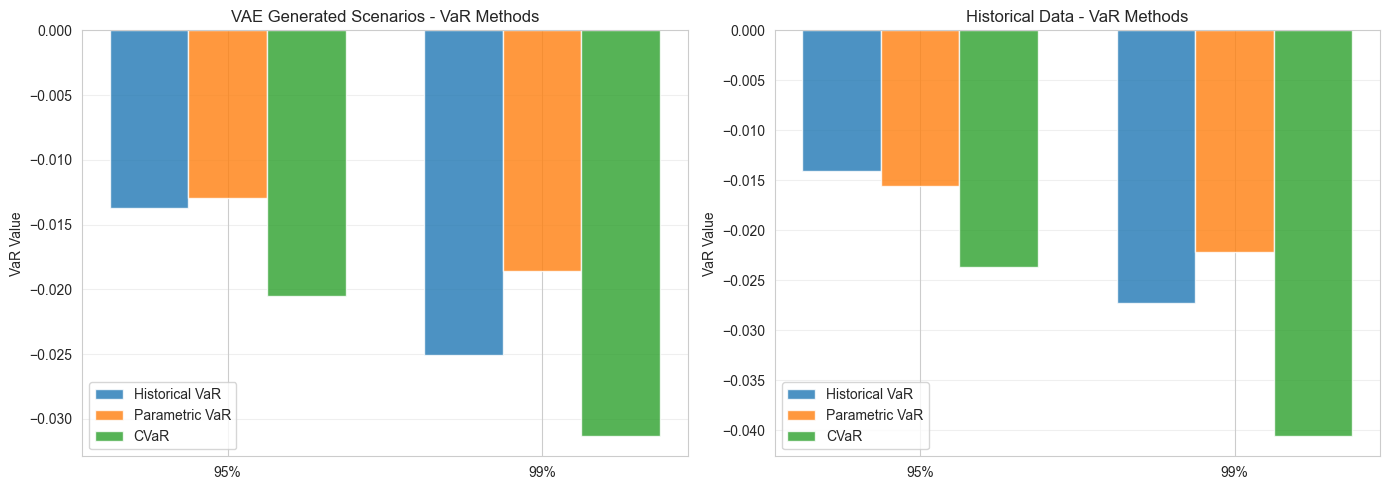

In [69]:
# Plot VaR methods comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generated scenarios
x = np.arange(len(var_summary_generated))
width = 0.25

axes[0].bar(x - width, var_summary_generated['Historical VaR'], width, label='Historical VaR', alpha=0.8)
axes[0].bar(x, var_summary_generated['Parametric VaR'], width, label='Parametric VaR', alpha=0.8)
axes[0].bar(x + width, var_summary_generated['CVaR'], width, label='CVaR', alpha=0.8)

axes[0].set_title('VAE Generated Scenarios - VaR Methods')
axes[0].set_ylabel('VaR Value')
axes[0].set_xticks(x)
axes[0].set_xticklabels(var_summary_generated['Confidence Level'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(0, color='black', linewidth=0.5)

# Historical data
axes[1].bar(x - width, var_summary_historical['Historical VaR'], width, label='Historical VaR', alpha=0.8)
axes[1].bar(x, var_summary_historical['Parametric VaR'], width, label='Parametric VaR', alpha=0.8)
axes[1].bar(x + width, var_summary_historical['CVaR'], width, label='CVaR', alpha=0.8)

axes[1].set_title('Historical Data - VaR Methods')
axes[1].set_ylabel('VaR Value')
axes[1].set_xticks(x)
axes[1].set_xticklabels(var_summary_historical['Confidence Level'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/07_var_methods_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Risk Metrics Summary

In [70]:
# Calculate additional risk metrics
from scipy import stats

metrics = {
    'Metric': [
        'Mean Return',
        'Std Deviation',
        'Skewness',
        'Kurtosis',
        'Min Return',
        'Max Return',
        'Sharpe Ratio (annual)'
    ],
    'Generated Scenarios': [
        generated_portfolio.mean(),
        generated_portfolio.std(),
        pd.Series(generated_portfolio).skew(),
        pd.Series(generated_portfolio).kurtosis(),
        generated_portfolio.min(),
        generated_portfolio.max(),
        (generated_portfolio.mean() / generated_portfolio.std() * np.sqrt(252))
    ],
    'Historical Data': [
        historical_portfolio_calc.mean(),
        historical_portfolio_calc.std(),
        pd.Series(historical_portfolio_calc).skew(),
        pd.Series(historical_portfolio_calc).kurtosis(),
        historical_portfolio_calc.min(),
        historical_portfolio_calc.max(),
        (historical_portfolio_calc.mean() / historical_portfolio_calc.std() * np.sqrt(252))
    ]
}

metrics_df = pd.DataFrame(metrics)

print("\n" + "="*80)
print("PORTFOLIO RISK METRICS SUMMARY")
print("="*80)
print(metrics_df.to_string(index=False))


PORTFOLIO RISK METRICS SUMMARY
               Metric  Generated Scenarios  Historical Data
          Mean Return             0.000475         0.000208
        Std Deviation             0.008177         0.009616
             Skewness            -0.632018        -0.687677
             Kurtosis             2.888313         8.176093
           Min Return            -0.062206        -0.073784
           Max Return             0.033365         0.071574
Sharpe Ratio (annual)             0.922513         0.342717


## 7. Risk Profiles Visualization

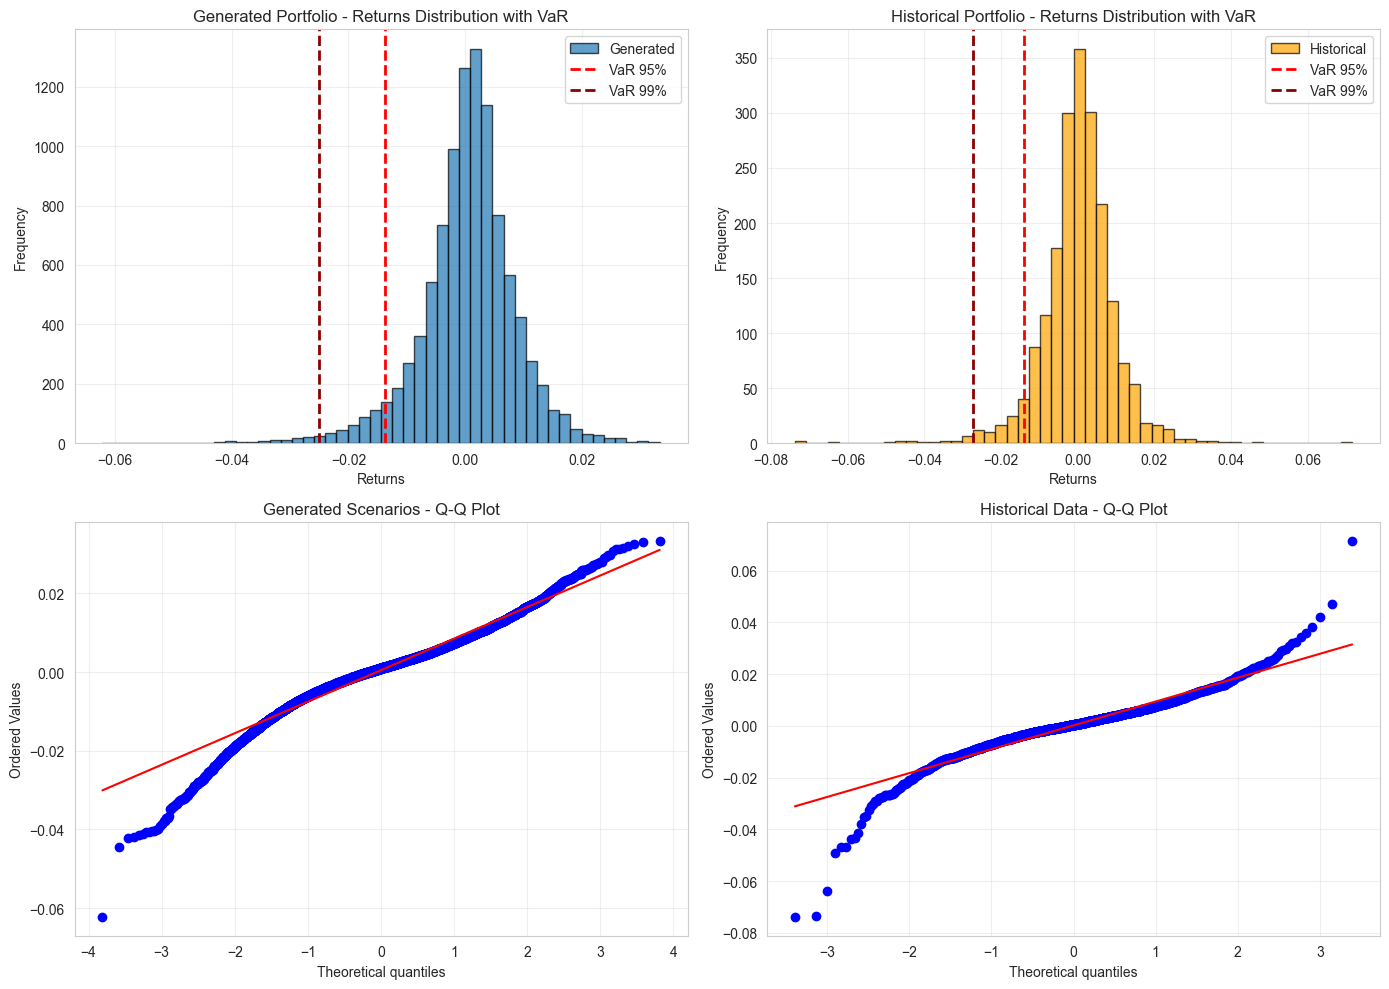

In [71]:
# Risk profile plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Returns distribution with VaR lines
axes[0, 0].hist(generated_portfolio, bins=50, alpha=0.7, label='Generated', edgecolor='black')
axes[0, 0].axvline(var_calc_generated.historical_var(0.95), color='red', linestyle='--', linewidth=2, label='VaR 95%')
axes[0, 0].axvline(var_calc_generated.historical_var(0.99), color='darkred', linestyle='--', linewidth=2, label='VaR 99%')
axes[0, 0].set_title('Generated Portfolio - Returns Distribution with VaR')
axes[0, 0].set_xlabel('Returns')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Historical returns distribution with VaR lines
axes[0, 1].hist(historical_portfolio_calc, bins=50, alpha=0.7, label='Historical', edgecolor='black', color='orange')
axes[0, 1].axvline(var_calc_historical.historical_var(0.95), color='red', linestyle='--', linewidth=2, label='VaR 95%')
axes[0, 1].axvline(var_calc_historical.historical_var(0.99), color='darkred', linestyle='--', linewidth=2, label='VaR 99%')
axes[0, 1].set_title('Historical Portfolio - Returns Distribution with VaR')
axes[0, 1].set_xlabel('Returns')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plots
stats.probplot(generated_portfolio, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Generated Scenarios - Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(historical_portfolio_calc, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Historical Data - Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/08_risk_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

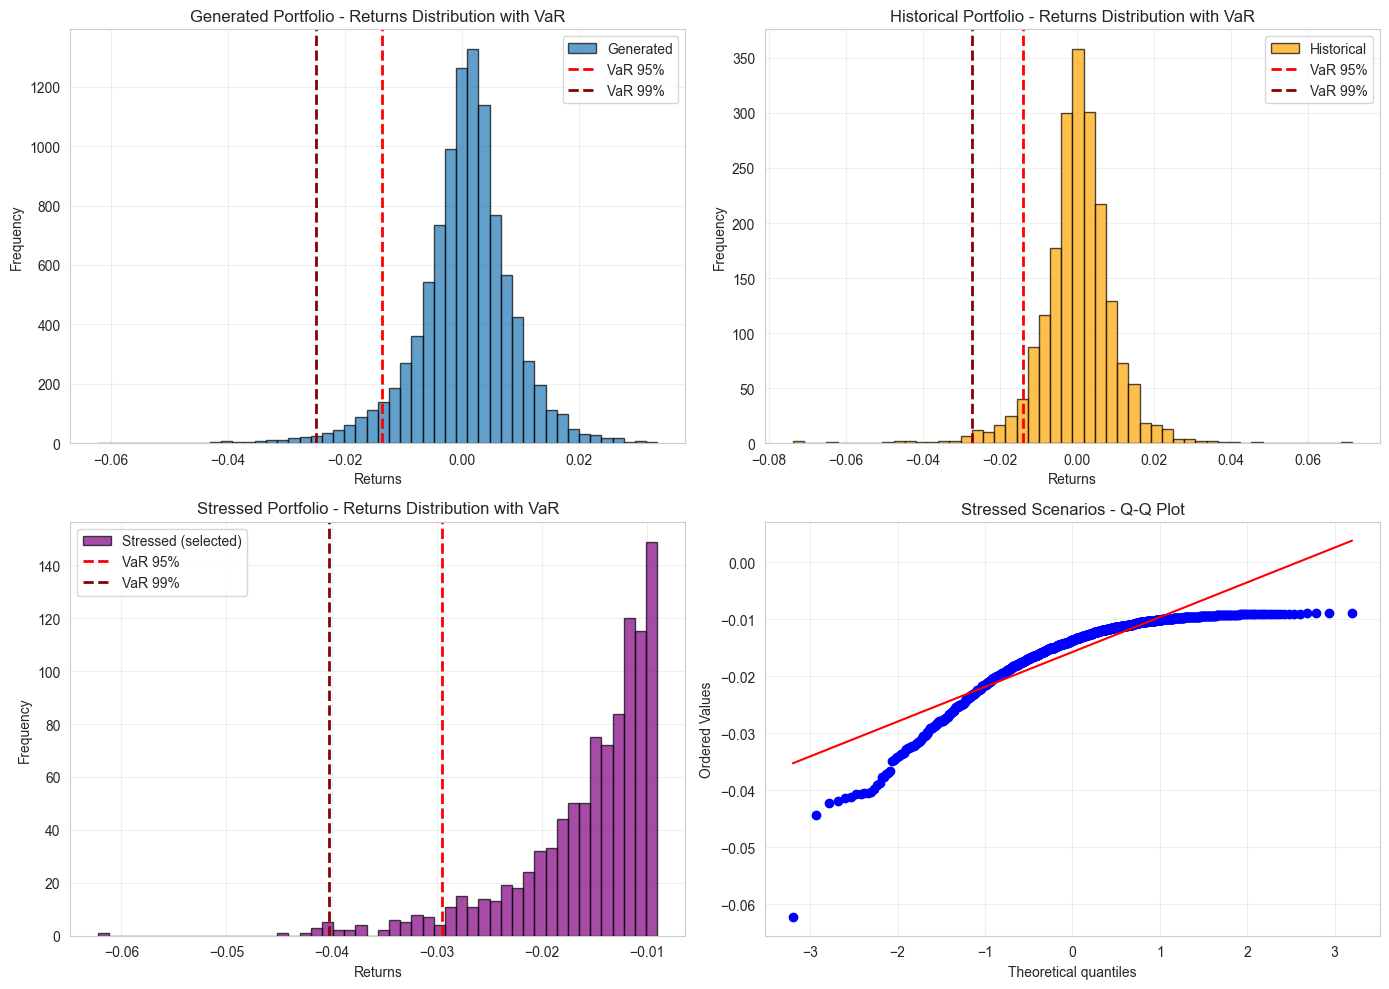

In [72]:
# 7b. Visualize stressed scenarios alongside generated and historical
import os

# Load stressed scenarios: prefer in-memory variable if present
try:
    selected_scenarios  # noqa: F821
    stressed_scenarios = selected_scenarios
except NameError:
    stressed_csv = '../results/stressed_scenarios.csv'
    if os.path.exists(stressed_csv):
        stressed_scenarios = pd.read_csv(stressed_csv).values
    else:
        print('Aucun fichier de scenarios stressés trouvé et variable in-memory manquante.')
        stressed_scenarios = None

if stressed_scenarios is not None:
    # normalize weights
    weights_norm = config.weights / config.weights.sum()
    stressed_portfolio = np.dot(stressed_scenarios, weights_norm)

    # VaR calculators (use existing if present)
    try:
        var_calc_stressed
    except NameError:
        var_calc_stressed = VaRCalculator(stressed_portfolio, config.weights)

    # Plot comparison: Generated | Historical | Stressed
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Generated (reuse existing)
    axes[0, 0].hist(generated_portfolio, bins=50, alpha=0.7, label='Generated', edgecolor='black')
    axes[0, 0].axvline(var_calc_generated.historical_var(0.95), color='red', linestyle='--', linewidth=2, label='VaR 95%')
    axes[0, 0].axvline(var_calc_generated.historical_var(0.99), color='darkred', linestyle='--', linewidth=2, label='VaR 99%')
    axes[0, 0].set_title('Generated Portfolio - Returns Distribution with VaR')
    axes[0, 0].set_xlabel('Returns')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Historical
    axes[0, 1].hist(historical_portfolio_calc, bins=50, alpha=0.7, label='Historical', edgecolor='black', color='orange')
    axes[0, 1].axvline(var_calc_historical.historical_var(0.95), color='red', linestyle='--', linewidth=2, label='VaR 95%')
    axes[0, 1].axvline(var_calc_historical.historical_var(0.99), color='darkred', linestyle='--', linewidth=2, label='VaR 99%')
    axes[0, 1].set_title('Historical Portfolio - Returns Distribution with VaR')
    axes[0, 1].set_xlabel('Returns')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Stressed
    axes[1, 0].hist(stressed_portfolio, bins=50, alpha=0.7, label='Stressed (selected)', edgecolor='black', color='purple')
    try:
        axes[1, 0].axvline(var_calc_stressed.historical_var(0.95), color='red', linestyle='--', linewidth=2, label='VaR 95%')
        axes[1, 0].axvline(var_calc_stressed.historical_var(0.99), color='darkred', linestyle='--', linewidth=2, label='VaR 99%')
    except Exception:
        pass
    axes[1, 0].set_title('Stressed Portfolio - Returns Distribution with VaR')
    axes[1, 0].set_xlabel('Returns')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Q-Q plot for stressed
    try:
        stats.probplot(stressed_portfolio, dist='norm', plot=axes[1, 1])
        axes[1, 1].set_title('Stressed Scenarios - Q-Q Plot')
        axes[1, 1].grid(True, alpha=0.3)
    except Exception as e:
        axes[1, 1].text(0.1, 0.5, f'Q-Q plot error: {e}')

    plt.tight_layout()
    plt.savefig('../results/09_stressed_vs_generated_historical.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Aucun scénario stressé disponible pour tracer les graphiques.')

## 8. Save Results

In [73]:
# Save all results
var_summary_generated.to_csv('../results/var_generated_scenarios.csv', index=False)
var_summary_historical.to_csv('../results/var_historical.csv', index=False)
metrics_df.to_csv('../results/risk_metrics.csv', index=False)

print("\n" + "="*80)
print("RESULTS SAVED")
print("="*80)
print("\nFiles saved in ../results/:")
print("  ✓ var_generated_scenarios.csv")
print("  ✓ var_historical.csv")
print("  ✓ risk_metrics.csv")
print("  ✓ 07_var_methods_comparison.png")
print("  ✓ 08_risk_profiles.png")
print("\n🎉 VAE Portfolio Project Completed Successfully!")


RESULTS SAVED

Files saved in ../results/:
  ✓ var_generated_scenarios.csv
  ✓ var_historical.csv
  ✓ risk_metrics.csv
  ✓ 07_var_methods_comparison.png
  ✓ 08_risk_profiles.png

🎉 VAE Portfolio Project Completed Successfully!
